a, b, c = -18.2584081647024 58149.56999718459 -46298557.70834485
parabola peak position = 1592.4052489307574
parabola peak height = 282.53494676947594


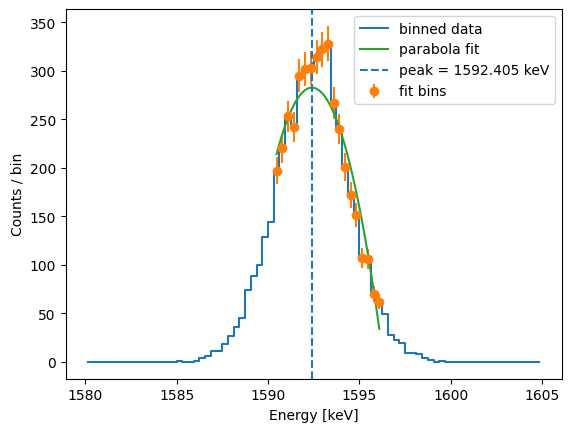

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Example: make fake binned peak data
# ------------------------------------------------------------
rng = np.random.default_rng(42)

# Imagine this is your energy variable
data = rng.normal(loc=1592.5, scale=2.0, size=5000)

# Histogram = binned data
counts, edges = np.histogram(data, bins=80, range=(1580, 1605))
centers = 0.5 * (edges[:-1] + edges[1:])

# ------------------------------------------------------------
# Parabola fit only near the peak top
# y = a x^2 + b x + c
# ------------------------------------------------------------
imax = np.argmax(counts)
x0_guess = centers[imax]

# choose local fit region, e.g. +- 3 keV around max bin
fit_mask = (centers > x0_guess - 3.0) & (centers < x0_guess + 3.0)

x_fit = centers[fit_mask]
y_fit = counts[fit_mask]

# optional: Poisson weights, sigma ~ sqrt(N)
sigma = np.sqrt(np.maximum(y_fit, 1))

# weighted quadratic fit
p, cov = np.polyfit(
    x_fit,
    y_fit,
    deg=2,
    w=1 / sigma,
    cov=True
)

a, b, c = p

# parabola vertex:
# dy/dx = 2 a x + b = 0
# x_peak = -b / (2a)
x_peak = -b / (2 * a)
y_peak = a * x_peak**2 + b * x_peak + c

print("a, b, c =", a, b, c)
print("parabola peak position =", x_peak)
print("parabola peak height =", y_peak)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
x_smooth = np.linspace(x_fit.min(), x_fit.max(), 300)
y_smooth = a * x_smooth**2 + b * x_smooth + c

plt.step(centers, counts, where="mid", label="binned data")
plt.errorbar(x_fit, y_fit, yerr=sigma, fmt="o", label="fit bins")
plt.plot(x_smooth, y_smooth, label="parabola fit")
plt.axvline(x_peak, linestyle="--", label=f"peak = {x_peak:.3f} keV")

plt.xlabel("Energy [keV]")
plt.ylabel("Counts / bin")
plt.legend()
plt.show()

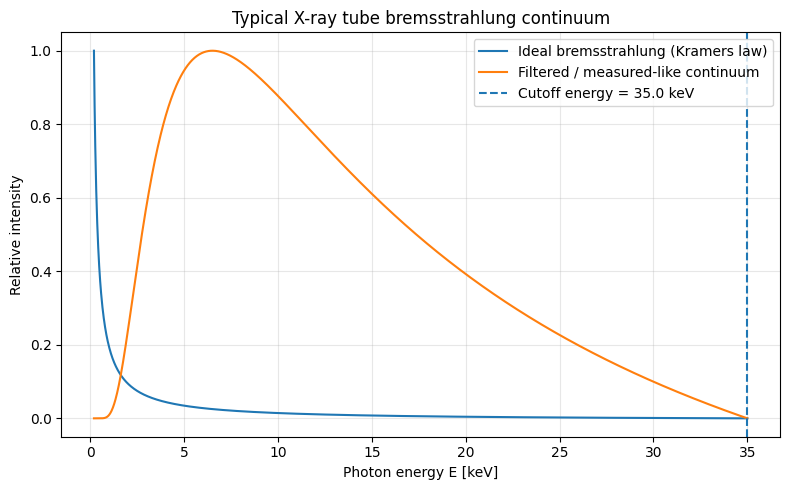

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
E0 = 35.0   # keV, tube voltage cutoff energy
E = np.linspace(0.2, E0, 2000)   # avoid E=0 because of 1/E

# ----------------------------
# Ideal bremsstrahlung continuum (Kramers-like)
# I(E) ~ (E0 - E) / E
# ----------------------------
I_ideal = (E0 - E) / E
I_ideal[E >= E0] = 0

# normalize
I_ideal = I_ideal / np.max(I_ideal)

# ----------------------------
# Add simple low-energy absorption
# This suppresses very low-energy photons
# to mimic window/filter/air absorption
# ----------------------------
alpha = 8.0   # strength of absorption
I_filtered = I_ideal * np.exp(-alpha / E)

# normalize again
I_filtered = I_filtered / np.max(I_filtered)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(E, I_ideal, label="Ideal bremsstrahlung (Kramers law)")
plt.plot(E, I_filtered, label="Filtered / measured-like continuum")

plt.axvline(E0, linestyle="--", label=f"Cutoff energy = {E0:.1f} keV")

plt.xlabel("Photon energy E [keV]")
plt.ylabel("Relative intensity")
plt.title("Typical X-ray tube bremsstrahlung continuum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
imax = np.argmax(counts)
x0_guess = centers[imax]

fit_mask = (centers > x0_guess - 3.0) & (centers < x0_guess + 3.0)

x_fit = centers[fit_mask]
y_fit = counts[fit_mask]

p, cov = np.polyfit(x_fit, y_fit, deg=2, w=1/np.sqrt(np.maximum(y_fit, 1)), cov=True)

a, b, c = p
x_peak = -b / (2*a)

In [3]:
import numpy as np
from scipy.optimize import curve_fit

def parabola_bin_integral(edges_for_fit, a, b, c):
    """
    Return expected counts in each bin by integrating
    f(x) = a*x^2 + b*x + c over each bin.
    """
    xL = edges_for_fit[:-1]
    xR = edges_for_fit[1:]

    return (
        a / 3 * (xR**3 - xL**3)
        + b / 2 * (xR**2 - xL**2)
        + c * (xR - xL)
    )

In [4]:
imax = np.argmax(counts)
x0_guess = centers[imax]

fit_mask = (centers > x0_guess - 3.0) & (centers < x0_guess + 3.0)

# Need the bin edges corresponding to the selected bins
idx = np.where(fit_mask)[0]
i0, i1 = idx[0], idx[-1]

counts_fit = counts[i0:i1+1]
edges_fit = edges[i0:i1+2]

sigma = np.sqrt(np.maximum(counts_fit, 1))

p0 = [-100, 2 * 100 * x0_guess, 1]  # rough initial guess; not very important

popt, pcov = curve_fit(
    parabola_bin_integral,
    edges_fit,
    counts_fit,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True
)

a, b, c = popt
x_peak = -b / (2*a)

print("peak position =", x_peak)

peak position = 1592.405262252379


Observed counts: [ 4 13 25 14  5]
Poisson sigma ≈ sqrt(N): [2.   3.61 5.   3.74 2.24]

Center fit parameters:
a, b, c = [-3.73737377 18.95316824 -4.74058786]
Peak position = 2.535626537121974

Bin-integral fit parameters:
a, b, c = [-3.73737372 18.95316798 -4.42913985]
Peak position = 2.5356265359677947


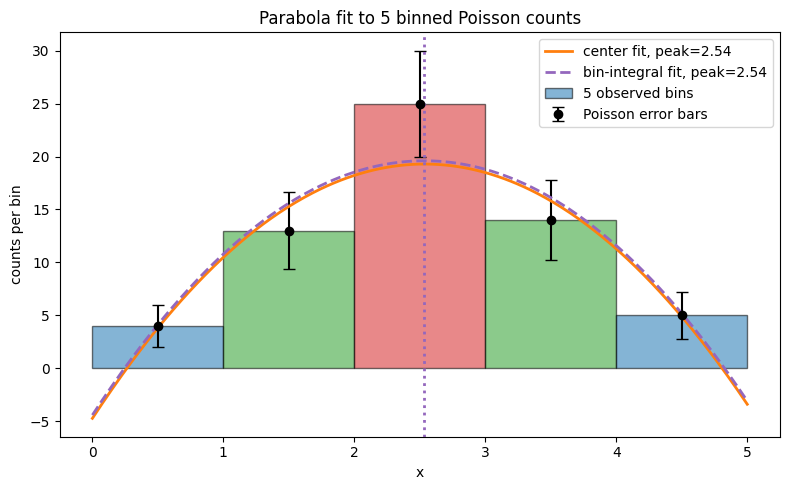

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Five binned data points: bin edges, centers, and observed counts
edges = np.array([0, 1, 2, 3, 4, 5], dtype=float)
centers = 0.5 * (edges[:-1] + edges[1:])
counts = np.array([4, 13, 25, 14, 5], dtype=float)

# Poisson uncertainty: sigma_i ≈ sqrt(N_i)
sigma = np.sqrt(np.maximum(counts, 1))

# Model 1: center approximation
# Count in bin i ≈ f(center_i)
def parabola_center(x, a, b, c):
    return a*x**2 + b*x + c

# Model 2: bin-integrated parabola
# Count in bin i = ∫_{left}^{right} (a x^2 + b x + c) dx
def parabola_integral(edges_for_fit, a, b, c):
    xL = edges_for_fit[:-1]
    xR = edges_for_fit[1:]
    return (
        a/3 * (xR**3 - xL**3)
        + b/2 * (xR**2 - xL**2)
        + c * (xR - xL)
    )

# Fit using Poisson weights
# Higher-count bins have smaller relative error, so they get more weight.
popt_center, pcov_center = curve_fit(
    parabola_center,
    centers,
    counts,
    sigma=sigma,
    absolute_sigma=True
)

popt_integral, pcov_integral = curve_fit(
    parabola_integral,
    edges,
    counts,
    sigma=sigma,
    absolute_sigma=True
)

a_c, b_c, c_c = popt_center
a_i, b_i, c_i = popt_integral

x_peak_center = -b_c / (2*a_c)
x_peak_integral = -b_i / (2*a_i)

print("Observed counts:", counts.astype(int))
print("Poisson sigma ≈ sqrt(N):", np.round(sigma, 2))
print()
print("Center fit parameters:")
print("a, b, c =", popt_center)
print("Peak position =", x_peak_center)
print()
print("Bin-integral fit parameters:")
print("a, b, c =", popt_integral)
print("Peak position =", x_peak_integral)

# Plot
x_smooth = np.linspace(edges[0], edges[-1], 400)
y_center = parabola_center(x_smooth, *popt_center)

# For visualizing the integral fit as a smooth density curve:
# The integral-fit function f(x) = a*x^2+b*x+c
y_integral_density = parabola_center(x_smooth, *popt_integral)

# Choose colors explicitly because user asked "color them"
bar_colors = ["tab:blue", "tab:green", "tab:red", "tab:green", "tab:blue"]

plt.figure(figsize=(8, 5))

plt.bar(
    centers,
    counts,
    width=np.diff(edges),
    align="center",
    alpha=0.55,
    edgecolor="black",
    color=bar_colors,
    label="5 observed bins"
)

plt.errorbar(
    centers,
    counts,
    yerr=sigma,
    fmt="o",
    color="black",
    capsize=4,
    label="Poisson error bars"
)

plt.plot(
    x_smooth,
    y_center,
    color="tab:orange",
    linewidth=2,
    label=f"center fit, peak={x_peak_center:.2f}"
)

plt.plot(
    x_smooth,
    y_integral_density,
    color="tab:purple",
    linestyle="--",
    linewidth=2,
    label=f"bin-integral fit, peak={x_peak_integral:.2f}"
)

plt.axvline(x_peak_integral, color="tab:purple", linestyle=":", linewidth=2)

plt.xlabel("x")
plt.ylabel("counts per bin")
plt.title("Parabola fit to 5 binned Poisson counts")
plt.legend()
plt.tight_layout()
plt.show()

Observed counts: [ 4 13 25 14  5]
Poisson sigma ≈ sqrt(N): [2.   3.61 5.   3.74 2.24]

Center fit parameters:
a, b, c = [-3.73737377 18.95316824 -4.74058786]
Peak position = 2.535626537121974

Bin-integral fit parameters:
a, b, c = [-3.73737372 18.95316798 -4.42913985]
Peak position = 2.5356265359677947


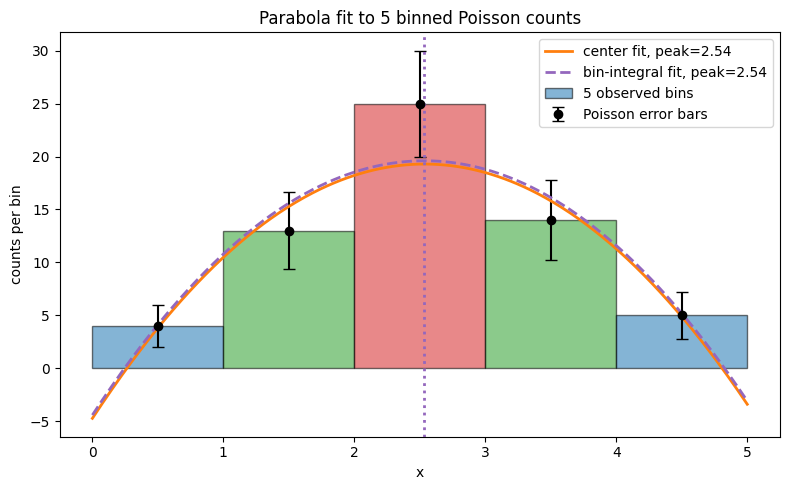

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Five binned data points: bin edges, centers, and observed counts
edges = np.array([0, 1, 2, 3, 4, 5], dtype=float)
centers = 0.5 * (edges[:-1] + edges[1:])
counts = np.array([4, 13, 25, 14, 5], dtype=float)

# Poisson uncertainty: sigma_i ≈ sqrt(N_i)
sigma = np.sqrt(np.maximum(counts, 1))

# Model 1: center approximation
# Count in bin i ≈ f(center_i)
def parabola_center(x, a, b, c):
    return a*x**2 + b*x + c

# Model 2: bin-integrated parabola
# Count in bin i = ∫_{left}^{right} (a x^2 + b x + c) dx
def parabola_integral(edges_for_fit, a, b, c):
    xL = edges_for_fit[:-1]
    xR = edges_for_fit[1:]
    return (
        a/3 * (xR**3 - xL**3)
        + b/2 * (xR**2 - xL**2)
        + c * (xR - xL)
    )

# Fit using Poisson weights
# Higher-count bins have smaller relative error, so they get more weight.
popt_center, pcov_center = curve_fit(
    parabola_center,
    centers,
    counts,
    sigma=sigma,
    absolute_sigma=True
)

popt_integral, pcov_integral = curve_fit(
    parabola_integral,
    edges,
    counts,
    sigma=sigma,
    absolute_sigma=True
)

a_c, b_c, c_c = popt_center
a_i, b_i, c_i = popt_integral

x_peak_center = -b_c / (2*a_c)
x_peak_integral = -b_i / (2*a_i)

print("Observed counts:", counts.astype(int))
print("Poisson sigma ≈ sqrt(N):", np.round(sigma, 2))
print()
print("Center fit parameters:")
print("a, b, c =", popt_center)
print("Peak position =", x_peak_center)
print()
print("Bin-integral fit parameters:")
print("a, b, c =", popt_integral)
print("Peak position =", x_peak_integral)

# Plot
x_smooth = np.linspace(edges[0], edges[-1], 400)
y_center = parabola_center(x_smooth, *popt_center)

# For visualizing the integral fit as a smooth density curve:
# The integral-fit function f(x) = a*x^2+b*x+c
y_integral_density = parabola_center(x_smooth, *popt_integral)

# Choose colors explicitly because user asked "color them"
bar_colors = ["tab:blue", "tab:green", "tab:red", "tab:green", "tab:blue"]

plt.figure(figsize=(8, 5))

plt.bar(
    centers,
    counts,
    width=np.diff(edges),
    align="center",
    alpha=0.55,
    edgecolor="black",
    color=bar_colors,
    label="5 observed bins"
)

plt.errorbar(
    centers,
    counts,
    yerr=sigma,
    fmt="o",
    color="black",
    capsize=4,
    label="Poisson error bars"
)

plt.plot(
    x_smooth,
    y_center,
    color="tab:orange",
    linewidth=2,
    label=f"center fit, peak={x_peak_center:.2f}"
)

plt.plot(
    x_smooth,
    y_integral_density,
    color="tab:purple",
    linestyle="--",
    linewidth=2,
    label=f"bin-integral fit, peak={x_peak_integral:.2f}"
)

plt.axvline(x_peak_integral, color="tab:purple", linestyle=":", linewidth=2)

plt.xlabel("x")
plt.ylabel("counts per bin")
plt.title("Parabola fit to 5 binned Poisson counts")
plt.legend()
plt.tight_layout()
plt.show()

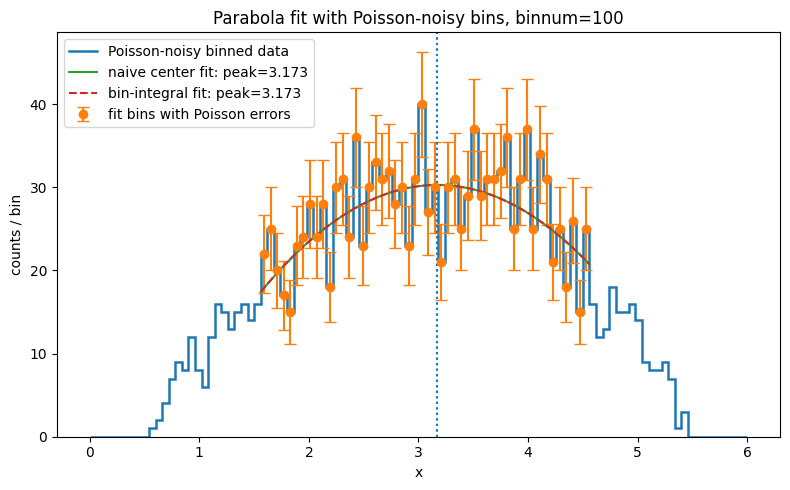

True peak position: 3.05
Naive center fit peak: 3.17280971446366
Bin-integral fit peak: 3.1728097100028556


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# User settings
# ============================================================
binnum = 100          # change this yourself
data_range = (0, 6)
fit_half_width = 1.5
rng = np.random.default_rng(42)

# ============================================================
# Make bin edges
# ============================================================
edges = np.linspace(data_range[0], data_range[1], binnum + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]

# ============================================================
# Define true underlying parabola
# This is a density-like curve, not yet counts per bin.
# ============================================================
def true_parabola(x):
    return -80 * (x - 3.05)**2 + 500

# ============================================================
# Expected counts per bin = integral of true curve over each bin
# ============================================================
def parabola_integral(edges_for_fit, a, b, c):
    xL = edges_for_fit[:-1]
    xR = edges_for_fit[1:]

    return (
        a / 3 * (xR**3 - xL**3)
        + b / 2 * (xR**2 - xL**2)
        + c * (xR - xL)
    )

# Convert true_parabola into ax^2 + bx + c:
# -80*(x-3.05)^2 + 500
# = -80*x^2 + 488*x - 244.2
a_true = -80
b_true = 2 * 80 * 3.05
c_true = 500 - 80 * 3.05**2

counts_expected = parabola_integral(edges, a_true, b_true, c_true)

# Make sure no expected count is negative
counts_expected = np.clip(counts_expected, 0, None)

# ============================================================
# Add Poisson noise to bins
# ============================================================
counts_noisy = rng.poisson(counts_expected, size=counts_expected.shape)

# Poisson uncertainty for fitting
sigma = np.sqrt(np.maximum(counts_noisy, 1))

# ============================================================
# Select peak-top region
# ============================================================
imax = np.argmax(counts_noisy)
x_peak_guess = centers[imax]

fit_mask = np.abs(centers - x_peak_guess) < fit_half_width

counts_fit = counts_noisy[fit_mask]
centers_fit = centers[fit_mask]
sigma_fit = sigma[fit_mask]

idx = np.where(fit_mask)[0]
i0, i1 = idx[0], idx[-1]
edges_fit = edges[i0:i1 + 2]

# ============================================================
# Naive center fit
# ============================================================
def parabola_center(x, a, b, c):
    return a*x**2 + b*x + c

popt_naive, pcov_naive = curve_fit(
    parabola_center,
    centers_fit,
    counts_fit,
    sigma=sigma_fit,
    absolute_sigma=True
)

a_n, b_n, c_n = popt_naive
x_peak_naive = -b_n / (2*a_n)

# ============================================================
# Correct bin-integral fit
# ============================================================
popt_integral, pcov_integral = curve_fit(
    parabola_integral,
    edges_fit,
    counts_fit,
    sigma=sigma_fit,
    absolute_sigma=True
)

a_i, b_i, c_i = popt_integral
x_peak_integral = -b_i / (2*a_i)

# ============================================================
# Plot
# ============================================================
x_plot = np.linspace(edges_fit[0], edges_fit[-1], 500)

y_naive = parabola_center(x_plot, *popt_naive)

# For visual comparison with counts/bin:
# integral-fit model is density-like, so multiply by bin width.
y_integral_visual = parabola_center(x_plot, *popt_integral) * bin_width

plt.figure(figsize=(8, 5))

plt.stairs(
    counts_noisy,
    edges,
    label="Poisson-noisy binned data",
    linewidth=1.8
)

plt.errorbar(
    centers_fit,
    counts_fit,
    yerr=sigma_fit,
    fmt="o",
    capsize=4,
    label="fit bins with Poisson errors"
)

plt.plot(
    x_plot,
    y_naive,
    label=f"naive center fit: peak={x_peak_naive:.3f}"
)

plt.plot(
    x_plot,
    y_integral_visual,
    "--",
    label=f"bin-integral fit: peak={x_peak_integral:.3f}"
)

plt.axvline(x_peak_naive, linestyle=":")
plt.axvline(x_peak_integral, linestyle=":")

plt.xlabel("x")
plt.ylabel("counts / bin")
plt.title(f"Parabola fit with Poisson-noisy bins, binnum={binnum}")
plt.legend()
plt.tight_layout()
plt.show()

print("True peak position:", 3.05)
print("Naive center fit peak:", x_peak_naive)
print("Bin-integral fit peak:", x_peak_integral)

Number of fit bins: 5
Fit range: 2.0 to 4.0


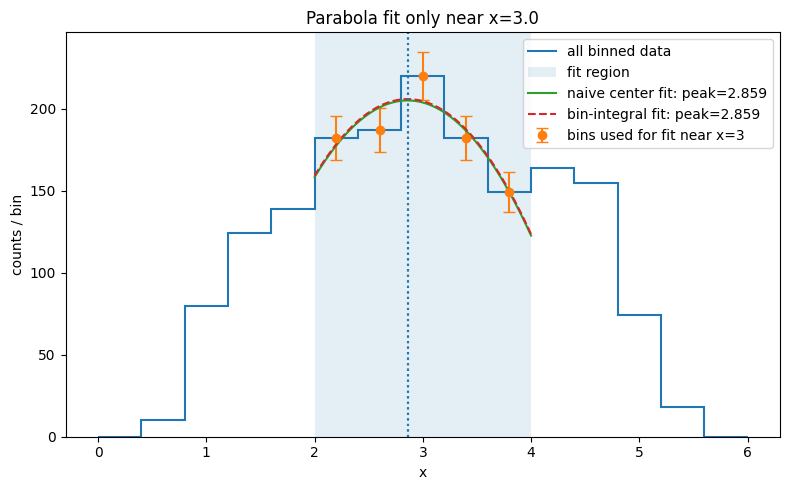

True peak position: 3.05
Naive center fit peak: 2.8590394426734806
Bin-integral fit peak: 2.8590394327705204


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# User settings
# ============================================================
binnum = 15
data_range = (0, 6)

x_center_guess = 3.0      # 你只想在 3 附近找
fit_half_width = 0.8      # 只用 [3-0.8, 3+0.8] 附近的 bins

rng = np.random.default_rng(42)

# ============================================================
# Make bin edges
# ============================================================
edges = np.linspace(data_range[0], data_range[1], binnum + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]

# ============================================================
# True underlying parabola
# ============================================================
def parabola_center(x, a, b, c):
    return a*x**2 + b*x + c

def parabola_integral(edges_for_fit, a, b, c):
    xL = edges_for_fit[:-1]
    xR = edges_for_fit[1:]

    return (
        a / 3 * (xR**3 - xL**3)
        + b / 2 * (xR**2 - xL**2)
        + c * (xR - xL)
    )

# true function: -80*(x-3.05)^2 + 500
a_true = -80
b_true = 2 * 80 * 3.05
c_true = 500 - 80 * 3.05**2

counts_expected = parabola_integral(edges, a_true, b_true, c_true)
counts_expected = np.clip(counts_expected, 0, None)

# Add Poisson noise
counts_noisy = rng.poisson(counts_expected)

# Poisson uncertainties
sigma = np.sqrt(np.maximum(counts_noisy, 1))

# ============================================================
# Select only bins near x = 3
# ============================================================
fit_mask = np.abs(centers - x_center_guess) < fit_half_width

counts_fit = counts_noisy[fit_mask]
centers_fit = centers[fit_mask]
sigma_fit = sigma[fit_mask]

# Need corresponding edges for bin-integral fit
idx = np.where(fit_mask)[0]
i0, i1 = idx[0], idx[-1]
edges_fit = edges[i0:i1 + 2]

print("Number of fit bins:", len(counts_fit))
print("Fit range:", edges_fit[0], "to", edges_fit[-1])

# ============================================================
# Safety check
# For a parabola you need at least 3 bins, but more is better.
# ============================================================
if len(counts_fit) < 3:
    raise ValueError("Need at least 3 bins for a parabola fit. Increase fit_half_width or binnum.")

# ============================================================
# 1. Naive center fit
# ============================================================
popt_naive, pcov_naive = curve_fit(
    parabola_center,
    centers_fit,
    counts_fit,
    sigma=sigma_fit,
    absolute_sigma=True
)

a_n, b_n, c_n = popt_naive
x_peak_naive = -b_n / (2*a_n)

# ============================================================
# 2. Bin-integral fit
# ============================================================
popt_integral, pcov_integral = curve_fit(
    parabola_integral,
    edges_fit,
    counts_fit,
    sigma=sigma_fit,
    absolute_sigma=True
)

a_i, b_i, c_i = popt_integral
x_peak_integral = -b_i / (2*a_i)

# ============================================================
# Plot
# ============================================================
x_plot = np.linspace(edges_fit[0], edges_fit[-1], 500)

y_naive = parabola_center(x_plot, *popt_naive)

# integral-fit gives density-like f(x), multiply by bin width for counts/bin plot
y_integral_visual = parabola_center(x_plot, *popt_integral) * bin_width

plt.figure(figsize=(8, 5))

plt.stairs(
    counts_noisy,
    edges,
    label="all binned data",
    linewidth=1.5
)

plt.errorbar(
    centers_fit,
    counts_fit,
    yerr=sigma_fit,
    fmt="o",
    capsize=4,
    label="bins used for fit near x=3"
)

plt.axvspan(
    edges_fit[0],
    edges_fit[-1],
    alpha=0.12,
    label="fit region"
)

plt.plot(
    x_plot,
    y_naive,
    label=f"naive center fit: peak={x_peak_naive:.3f}"
)

plt.plot(
    x_plot,
    y_integral_visual,
    "--",
    label=f"bin-integral fit: peak={x_peak_integral:.3f}"
)

plt.axvline(x_peak_naive, linestyle=":")
plt.axvline(x_peak_integral, linestyle=":")

plt.xlabel("x")
plt.ylabel("counts / bin")
plt.title(f"Parabola fit only near x={x_center_guess}")
plt.legend()
plt.tight_layout()
plt.show()

print("True peak position:", 3.05)
print("Naive center fit peak:", x_peak_naive)
print("Bin-integral fit peak:", x_peak_integral)

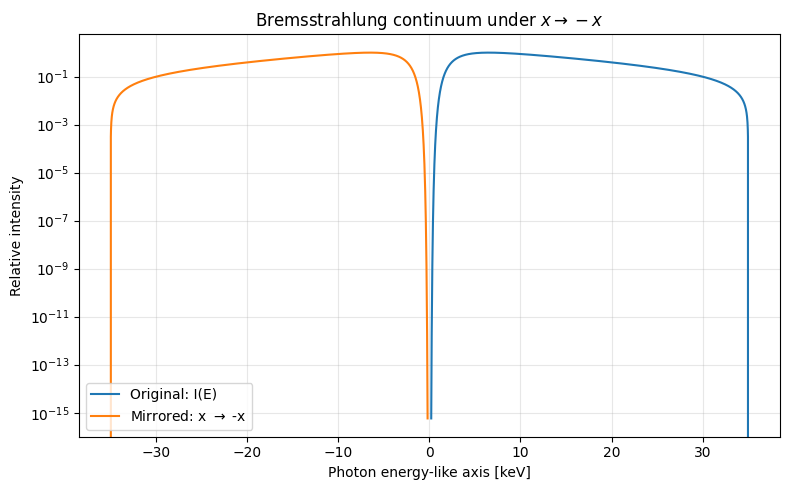

In [3]:
import numpy as np
import matplotlib.pyplot as plt

E0 = 35.0
E = np.linspace(0.2, E0, 2000)

I_ideal = (E0 - E) / E
I_ideal[E >= E0] = 0
I_ideal = I_ideal / np.max(I_ideal)

alpha = 8.0
I_filtered = I_ideal * np.exp(-alpha / E)
I_filtered = I_filtered / np.max(I_filtered)

# x -> -x
E_mirror = -E

plt.figure(figsize=(8, 5))

plt.plot(E, I_filtered, label="Original: I(E)")
plt.plot(E_mirror, I_filtered, label=r"Mirrored: x $\to$ -x")

plt.xlabel("Photon energy-like axis [keV]")
plt.ylabel("Relative intensity")
plt.title(r"Bremsstrahlung continuum under $x \to -x$")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.special import erfc

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def left_exgauss_tail(x, A, mu, sigma, tau):
    """
    Exponential tail to the left of a Gaussian peak.
    tau > 0 controls tail length.
    """
    lam = 1.0 / tau

    return (
        A * lam / 2
        * np.exp(
            lam * (x - mu)
            + 0.5 * (lam * sigma)**2
        )
        * erfc(
            (x - mu + lam * sigma**2) / (np.sqrt(2) * sigma)
        )
    )

def aoe_peak_plus_slow_tail(x, A_peak, mu, sigma, A_tail, tau, C):
    return (
        gaussian(x, A_peak, mu, sigma)
        + left_exgauss_tail(x, A_tail, mu, sigma, tau)
        + C
    )
    

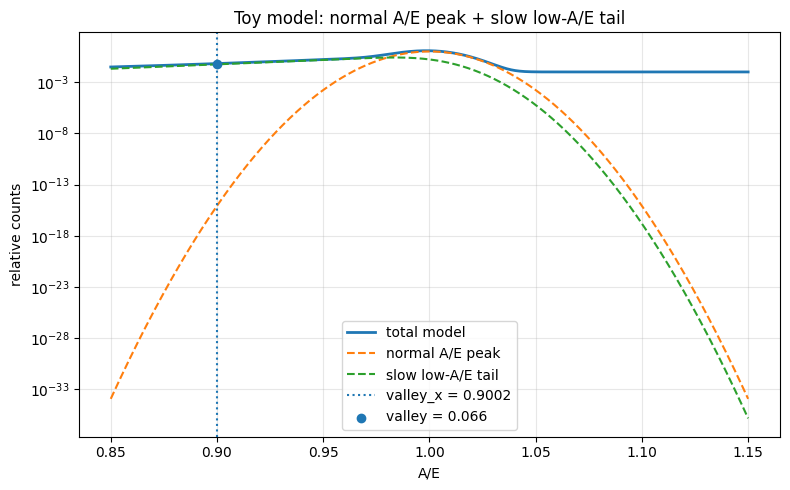

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc


def gaussian(x, A, mu, sigma):
    """
    Normal A/E peak.
    """
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def left_exgauss_tail(x, A, mu, sigma, tau):
    """
    Left-sided exponentially modified Gaussian tail.

    This represents slow-pulse / dead-layer-like events that create
    a low-A/E shoulder to the left of the main peak.

    tau > 0 controls the tail length.
    Larger tau -> longer low-A/E tail.
    """
    lam = 1.0 / tau

    return (
        A * lam / 2.0
        * np.exp(
            lam * (x - mu)
            + 0.5 * (lam * sigma) ** 2
        )
        * erfc(
            (x - mu + lam * sigma**2) / (np.sqrt(2) * sigma)
        )
    )


def aoe_peak_plus_slow_tail(x, A_peak, mu, sigma, A_tail, tau, C):
    """
    Total toy model:
        normal SSE-like A/E peak
        +
        low-A/E slow-pulse tail
        +
        constant background
    """
    peak = gaussian(x, A_peak, mu, sigma)
    tail = left_exgauss_tail(x, A_tail, mu, sigma, tau)
    bg = C * np.ones_like(x)

    return peak + tail + bg


# --------------------------------------------------
# Example parameters
# --------------------------------------------------
x = np.linspace(0.85, 1.15, 1000)

A_peak = 1.0
mu = 1.000
sigma = 0.012

A_tail = 0.020
tau = 0.050

C = 0.01

peak_component = gaussian(x, A_peak, mu, sigma)
tail_component = left_exgauss_tail(x, A_tail, mu, sigma, tau)
total_model = aoe_peak_plus_slow_tail(x, A_peak, mu, sigma, A_tail, tau, C)

# --------------------------------------------------
# Find valley between slow tail and main peak
# Choose a reasonable search region left of the main peak
# --------------------------------------------------
valley_search = (x > 0.90) & (x < 0.99)
valley_idx = np.argmin(total_model[valley_search])
valley_x = x[valley_search][valley_idx]
valley_y = total_model[valley_search][valley_idx]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(x, total_model, label="total model", linewidth=2)
plt.plot(x, peak_component, "--", label="normal A/E peak")
plt.plot(x, tail_component, "--", label="slow low-A/E tail")

plt.axvline(
    valley_x,
    linestyle=":",
    label=f"valley_x = {valley_x:.4f}",
)

plt.scatter(
    [valley_x],
    [valley_y],
    zorder=5,
    label=f"valley = {valley_y:.3f}",
)

plt.xlabel("A/E")
plt.ylabel("relative counts")
plt.title("Toy model: normal A/E peak + slow low-A/E tail")
plt.grid(alpha=0.3)
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import ipywidgets as widgets
from IPython.display import display


def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def left_exgauss_tail(x, A, mu_tail, sigma_tail, tau):
    """
    Left-sided exponentially modified Gaussian tail.

    mu_tail:
        location where the slow tail is anchored / smeared endpoint

    sigma_tail:
        smearing width of the tail endpoint

    tau:
        left-tail length scale
    """
    lam = 1.0 / tau

    return (
        A * lam / 2.0
        * np.exp(
            lam * (x - mu_tail)
            + 0.5 * (lam * sigma_tail) ** 2
        )
        * erfc(
            (x - mu_tail + lam * sigma_tail**2) / (np.sqrt(2) * sigma_tail)
        )
    )


def aoe_peak_plus_slow_tail(
    x,
    A_peak,
    mu_peak,
    sigma_peak,
    A_tail,
    mu_tail,
    sigma_tail,
    tau,
    C,
):
    peak = gaussian(x, A_peak, mu_peak, sigma_peak)
    tail = left_exgauss_tail(x, A_tail, mu_tail, sigma_tail, tau)
    bg = C * np.ones_like(x)

    return peak + tail + bg


x = np.linspace(0.85, 1.15, 1200)


def plot_toy_model(
    A_peak=1.0,
    mu_peak=1.000,
    sigma_peak=0.012,
    A_tail=0.020,
    mu_tail=0.970,
    sigma_tail=0.015,
    tau=0.050,
    C=0.010,
    log_y=True,
):
    peak_component = gaussian(x, A_peak, mu_peak, sigma_peak)
    tail_component = left_exgauss_tail(x, A_tail, mu_tail, sigma_tail, tau)
    total_model = aoe_peak_plus_slow_tail(
        x,
        A_peak,
        mu_peak,
        sigma_peak,
        A_tail,
        mu_tail,
        sigma_tail,
        tau,
        C,
    )

    valley_search = (x > 0.88) & (x < mu_peak)

    if np.any(valley_search):
        idx = np.argmin(total_model[valley_search])
        valley_x = x[valley_search][idx]
        valley_y = total_model[valley_search][idx]
    else:
        valley_x = np.nan
        valley_y = np.nan

    plt.figure(figsize=(8, 5))

    plt.plot(x, total_model, linewidth=2, label="total model")
    plt.plot(x, peak_component, "--", label=r"normal peak")
    plt.plot(x, tail_component, "--", label=r"slow low-A/E tail")
    plt.axhline(C, linestyle=":", label="constant background")

    plt.axvline(mu_peak, linestyle="--", alpha=0.5, label=fr"$\mu_{{peak}}$ = {mu_peak:.3f}")
    plt.axvline(mu_tail, linestyle="--", alpha=0.5, label=fr"$\mu_{{tail}}$ = {mu_tail:.3f}")

    if np.isfinite(valley_x):
        plt.axvline(
            valley_x,
            linestyle=":",
            label=f"valley_x = {valley_x:.4f}",
        )
        plt.scatter(
            [valley_x],
            [valley_y],
            zorder=5,
            label=f"valley count = {valley_y:.3g}",
        )

    plt.xlabel("A/E")
    plt.ylabel("relative counts")
    plt.title("Toy model: normal A/E peak + slow low-A/E tail")
    plt.grid(alpha=0.3)

    if log_y:
        plt.yscale("log")
        positive = total_model[total_model > 0]
        if len(positive) > 0:
            plt.ylim(bottom=max(1e-5, np.nanmin(positive) * 0.5))

    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


ui = widgets.interactive(
    plot_toy_model,
    A_peak=widgets.FloatSlider(
        value=1.0, min=0.1, max=3.0, step=0.05, description="A_peak"
    ),
    mu_peak=widgets.FloatSlider(
        value=1.000, min=0.970, max=2.030, step=0.001, description="mu_peak"
    ),
    sigma_peak=widgets.FloatSlider(
        value=0.012, min=0.003, max=0.060, step=0.001, description="sig_peak"
    ),
    A_tail=widgets.FloatSlider(
        value=0.020, min=0.000, max=0.300, step=0.005, description="A_tail"
    ),
    mu_tail=widgets.FloatSlider(
        value=0.970, min=0.850, max=1.030, step=0.001, description="mu_tail"
    ),
    sigma_tail=widgets.FloatSlider(
        value=0.015, min=0.003, max=0.060, step=0.001, description="sig_tail"
    ),
    tau=widgets.FloatSlider(
        value=0.050, min=0.005, max=0.250, step=0.005, description="tau"
    ),
    C=widgets.FloatSlider(
        value=0.010, min=0.000, max=0.100, step=0.002, description="C"
    ),
    log_y=widgets.Checkbox(
        value=True, description="log y"
    ),
)

display(ui)

interactive(children=(FloatSlider(value=1.0, description='A_peak', max=3.0, min=0.1, step=0.05), FloatSlider(v…